In [3]:
import xarray as xr
from scipy.stats import pearsonr

import os.path
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import netCDF4
import matplotlib.pyplot as plt
from matplotlib import dates

import eatpy
from scipy.stats import qmc,spearmanr,pearsonr,iqr
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import glob

setup_dir = "."
varname = ["1p1z_no3","1p1z_chl","1p1z_SDeN","1p1z_LDeN"]

In [163]:
# Read in the ensemble size defined in a py file.
from importlib import reload
import generate_ensemble_yaml

# Reload the module
reload(generate_ensemble_yaml)

# Access the variable through the module
N = generate_ensemble_yaml.N

In [232]:
# Read in the ensemble parameter sets defined in a csv file.
sample_scaled = pd.read_csv('parameter-values-'+str(N)+'.csv')
name_para = sample_scaled.columns.tolist() # header, parameter names
sample_scaled

,attCHL,I_thNH4,D_p5NH4,NitriR,K_NO3,K_NH4,Vp0,K_Phy,PhyIS,PhyMR,...,ZooBM,ZooER,ZooGR,ZooMR,LDeRRN,SDeRRN,CoagR,wP,wL,wS
0,0.017,0.010,0.09,0.38,1.6,2.7,1.9,1.9,0.058,0.16,...,0.28,0.16,3.7,0.25,0.030,0.046,0.368,1.11,4.1,0.31
1,0.020,0.013,0.06,0.13,4.1,2.3,2.6,1.8,0.081,0.04,...,0.27,0.23,1.3,0.16,0.455,0.043,0.055,0.73,7.2,0.99
2,0.034,0.015,0.15,0.18,1.0,4.8,2.5,1.1,0.107,0.02,...,0.18,0.04,1.7,0.32,0.226,0.007,0.710,0.33,3.9,0.83
3,0.042,0.012,0.15,0.36,1.2,3.6,3.3,4.6,0.029,0.20,...,0.11,0.05,2.7,0.29,0.052,0.065,0.222,1.36,6.0,0.15
4,0.032,0.014,0.06,0.33,4.0,3.0,1.5,1.9,0.130,0.24,...,0.14,0.28,1.2,0.03,0.440,0.022,0.525,1.28,5.4,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.046,0.014,0.12,0.18,3.5,0.9,2.6,2.3,0.075,0.13,...,0.11,0.23,0.3,0.20,0.177,0.022,0.614,0.16,6.6,0.79
2996,0.021,0.011,0.15,0.02,4.3,1.7,2.7,2.4,0.033,0.03,...,0.18,0.31,1.9,0.09,0.399,0.088,0.062,0.36,7.4,1.19
2997,0.042,0.010,0.10,0.15,0.8,4.0,1.1,3.1,0.024,0.16,...,0.09,0.35,2.8,0.19,0.139,0.035,0.092,0.74,9.8,0.61
2998,0.041,0.008,0.12,0.25,4.0,0.5,1.2,4.2,0.125,0.08,...,0.26,0.14,0.6,0.26,0.462,0.046,0.713,0.95,5.2,1.23


### Read ensemble outputs

In [165]:
import xarray as xr
import glob

# ファイルパスのリストを作成
file_paths = sorted(glob.glob("result_[0-9][0-9][0-9][0-9].nc"))

# `xr.open_mfdataset` を使用してファイルを結合
ds = xr.open_mfdataset(
    file_paths,
    concat_dim="ensemble",  # 新しい次元として 'ensemble' を追加
    combine="nested",       # 結合方法
    coords="minimal",       # 必要最小限の座標のみを保持
    compat="override",      # メタデータの競合を無視
    parallel=True,          # 並列処理を有効化（高速化）
)

# 'ensemble' 次元に番号を割り当てる
ds = ds.assign_coords(ensemble=range(len(file_paths)))

# 変数の抽出
time = ds['time']
z = ds['z'][0, :, 0, 0]

In [166]:
ds

<xarray.Dataset> Size: 39GB
Dimensions:                                                   (ensemble: 3000,
                                                               time: 366,
                                                               z: 110, lat: 1,
                                                               lon: 1, zi: 111)
Coordinates:
  * time                                                      (time) datetime64[ns] 3kB ...
  * lon                                                       (lon) float32 4B ...
  * lat                                                       (lat) float32 4B ...
    z                                                         (time, z, lat, lon) float32 161kB dask.array<chunksize=(366, 110, 1, 1), meta=np.ndarray>
    zi                                                        (time, zi, lat, lon) float32 163kB dask.array<chunksize=(366, 111, 1, 1), meta=np.ndarray>
  * ensemble                                                  (ensemble) int64 24kB ...
Data variables: (12/123)
    temp                                                      (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    salt                                                      (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    rho                                                       (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    temp_obs                                                  (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    salt_obs                                                  (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    u                                                         (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    ...                                                        ...
    1p1z_RemineL                                              (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    1p1z_Nitrifi                                              (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    light_par                                                 (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    attenuation_coefficient_of_photosynthetic_radiative_flux  (ensemble, time, z, lat, lon) float32 483MB dask.array<chunksize=(1, 366, 110, 1, 1), meta=np.ndarray>
    surface_drag_coefficient_in_air                           (ensemble, time, lat, lon) float32 4MB dask.array<chunksize=(1, 366, 1, 1), meta=np.ndarray>
    surface_albedo                                            (ensemble, time, lat, lon) float32 4MB dask.array<chunksize=(1, 366, 1, 1), meta=np.ndarray>
Attributes:
    title:    GOTM Simulation
    comment:  file created by flexout - https://github.com/BoldingBruggeman/f...

### Sea surface chlorophyll-a sensitivity

ValueError: could not convert string to float: np.str_('1.3804e')

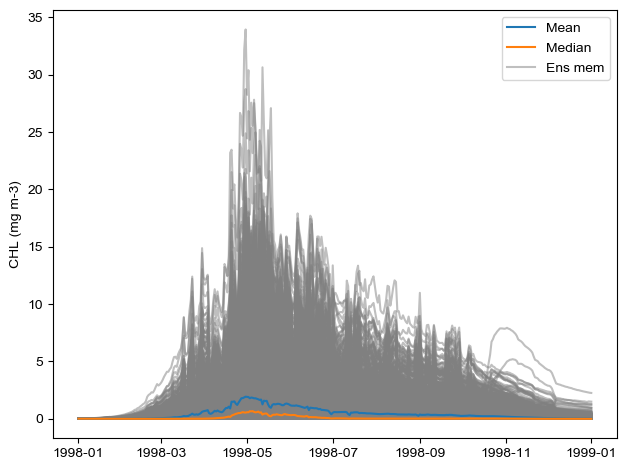

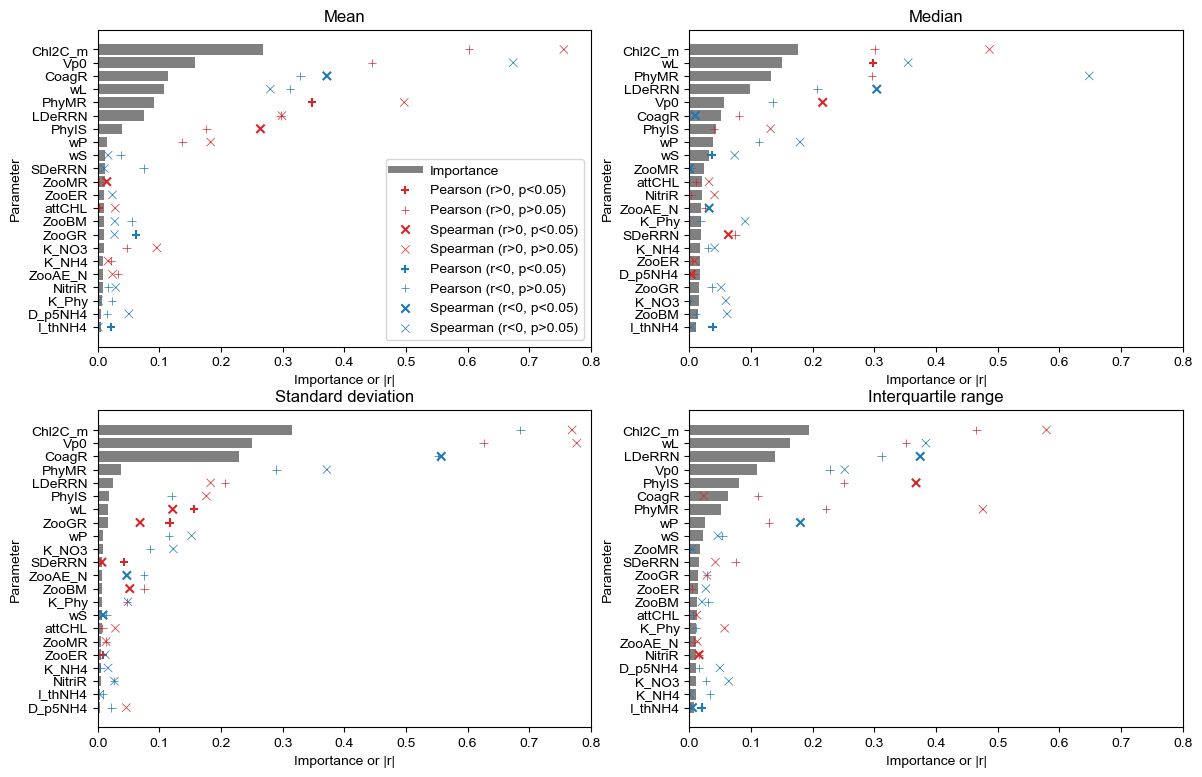

In [229]:
# obtain vertical time series (ensemble member, time, depth) of a selected variable
temps = ds["1p1z_chl"][:,:,:,0, 0].values
# obtain time series in the uppermost layer (compare with satellite)
ssts = temps[:,:,-1]

plt.figure()
# loop over ensemble members
for j in range(np.size(ssts,0)):
    plt.plot(time,ssts[j,:],c='gray',alpha=0.5)
plt.plot(time,np.mean(ssts,0),label='Mean')
plt.plot(time,np.median(ssts,0),label='Median')
plt.plot([],[],c='gray',alpha=0.5,label='Ens mem')
plt.ylabel('CHL (mg m-3)')
plt.legend()
plt.tight_layout()
plt.savefig('fig-SSCHL-'+str(N),dpi=300,bbox_inches='tight')


# calculate different metrics
n_metric = ['Mean','Median','Standard deviation','Interquartile range','Max','Day of Max']
v_metric = [np.mean(ssts,1),
            np.median(ssts,1),
            np.std(ssts,1),
            iqr(ssts,1),
            np.max(ssts,1),
            np.argmax(ssts,1) # note this is the index and not the datetime so that correlation can be calculated
           ]

fig = plt.figure(figsize=(14, 14))

for j in range(np.size(n_metric)):

    output = v_metric[j]
    sample_scaled['target'] = output
    
    r_spearman = np.zeros_like(name_para)
    r_pearson = np.zeros_like(name_para)
    p_spearman = np.zeros_like(name_para)
    p_pearson = np.zeros_like(name_para)
    for i in range(len(name_para)):
        res = sample_scaled.partial_corr(
            x='target',
            y=name_para[i],
            covar=[ii for ii in name_para if ii != name_para[i]],
            method = 'spearman'
        )
        r_spearman[i],p_spearman[i] = float(res['r'].values),float(res['p-val'].values)
        res = sample_scaled.partial_corr(
            x='target',
            y=name_para[i],
            covar=[ii for ii in name_para if ii != name_para[i]],
            method = 'pearson'
        )
        r_pearson[i],p_pearson[i] = float(res['r'].values),float(res['p-val'].values)
    r_spearman = r_spearman.astype(float)
    p_spearman = p_spearman.astype(float)
    r_pearson = r_pearson.astype(float)
    p_pearson = p_pearson.astype(float)
    
    c_spearman = []
    c_pearson = []
    lws_spearman = []
    lws_pearson = []
    for i in range(len(name_para)):
        if r_spearman[i] < 0:
            c_spearman.append('tab:blue')
        elif r_spearman[i] > 0:
            c_spearman.append('tab:red')
        else:
            c_spearman.append('tab:gray') # rare case (r = 0)
        if p_spearman[i] < 0.05:
            lws_spearman.append(1.5)
        elif p_spearman[i] > 0.05:
            lws_spearman.append(0.5)
        else:
            lws_spearman.append(5) # rare case 
                
    for i in range(len(name_para)):
        if r_pearson[i] < 0:
            c_pearson.append('tab:blue')
        elif r_pearson[i] > 0:
            c_pearson.append('tab:red')
        else:
            c_pearson.append('tab:gray') # rare case (r = 0)
        if p_pearson[i] < 0.05:
            lws_pearson.append(1.5)
        elif p_pearson[i] > 0.05:
            lws_pearson.append(0.5)
        else:
            lws_pearson.append(5) # rare case (p = 0.05)


    rf = RandomForestRegressor()
    rf.fit(sample_scaled.drop(columns=['target']), sample_scaled['target'])
    importances = rf.feature_importances_
    
    
    df = pd.DataFrame({
        "Parameter": name_para,
        "Importance": importances,
        "absR-Pearson":np.abs(r_pearson),
        "absR-Spearman":np.abs(r_spearman),
    }).sort_values(by="Importance", ascending=False)

    plt.subplot(3,2,j+1)
    
    sns.barplot(data=df, x="Importance", y="Parameter",color='gray')
    sns.scatterplot(data=df, x="absR-Pearson", y="Parameter",color=c_pearson,marker='+',linewidths=lws_pearson)
    sns.scatterplot(data=df, x="absR-Spearman", y="Parameter",color=c_spearman,marker='x',linewidths=lws_spearman)
    plt.title(n_metric[j])
    plt.xlabel('Importance or |r|')
    if j == 0:
        plt.plot([],[],lw=5,color='gray',label='Importance')
        plt.scatter([],[],color='tab:red',marker='+',linewidths=1.5,label='Pearson (r>0, p<0.05)')
        plt.scatter([],[],color='tab:red',marker='+',linewidths=0.5,label='Pearson (r>0, p>0.05)')
        plt.scatter([],[],color='tab:red',marker='x',linewidths=1.5,label='Spearman (r>0, p<0.05)')
        plt.scatter([],[],color='tab:red',marker='x',linewidths=0.5,label='Spearman (r>0, p>0.05)')
        plt.scatter([],[],color='tab:blue',marker='+',linewidths=1.5,label='Pearson (r<0, p<0.05)')
        plt.scatter([],[],color='tab:blue',marker='+',linewidths=0.5,label='Pearson (r<0, p>0.05)')
        plt.scatter([],[],color='tab:blue',marker='x',linewidths=1.5,label='Spearman (r<0, p<0.05)')
        plt.scatter([],[],color='tab:blue',marker='x',linewidths=0.5,label='Spearman (r<0, p>0.05)')
        plt.legend()
    plt.xlim(0, 0.8)
plt.tight_layout()
plt.savefig('fig-sensitivity2-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

### Sea surface chlorophyll-a sensitivity at different lead times

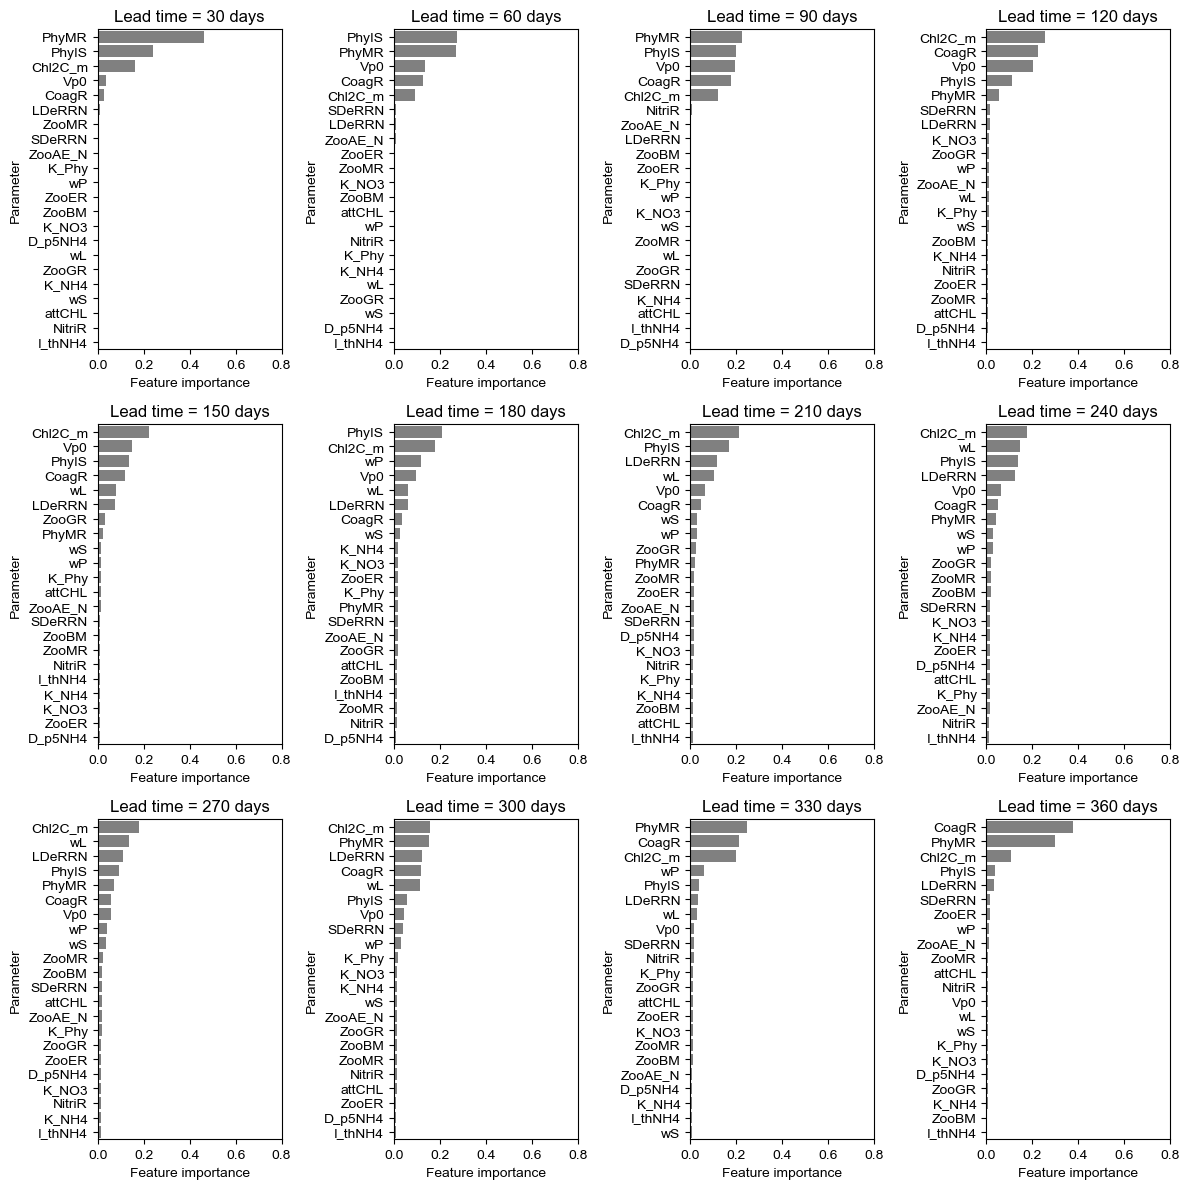

In [233]:
# obtain vertical time series (ensemble member, time, depth) of a selected variable
temps = ds["1p1z_chl"][:,:,:,0, 0].values
# obtain time series in the uppermost layer (compare with satellite)
ssts = temps[:,:,-1]

fig = plt.figure(figsize=(12, 12))

leadtime = 0
for j in range(12):

    leadtime += 30 # add 30 days
    output = ssts[:,leadtime]

    rf = RandomForestRegressor()
    rf.fit(sample_scaled, output)
    importances = rf.feature_importances_
    
    
    df = pd.DataFrame({
        "Parameter": name_para,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.subplot(3,4,j+1)
    
    sns.barplot(data=df, x="Importance", y="Parameter",color='gray')
    plt.title('Lead time = '+str(leadtime)+' days')
    plt.xlabel('Feature importance')
    plt.xlim(0, 0.8)
plt.tight_layout()
plt.savefig('fig-sensitivity-leadtime-SSCHL-'+str(N),dpi=300,bbox_inches='tight')

### Biogeochemical (this is the bottleneck)

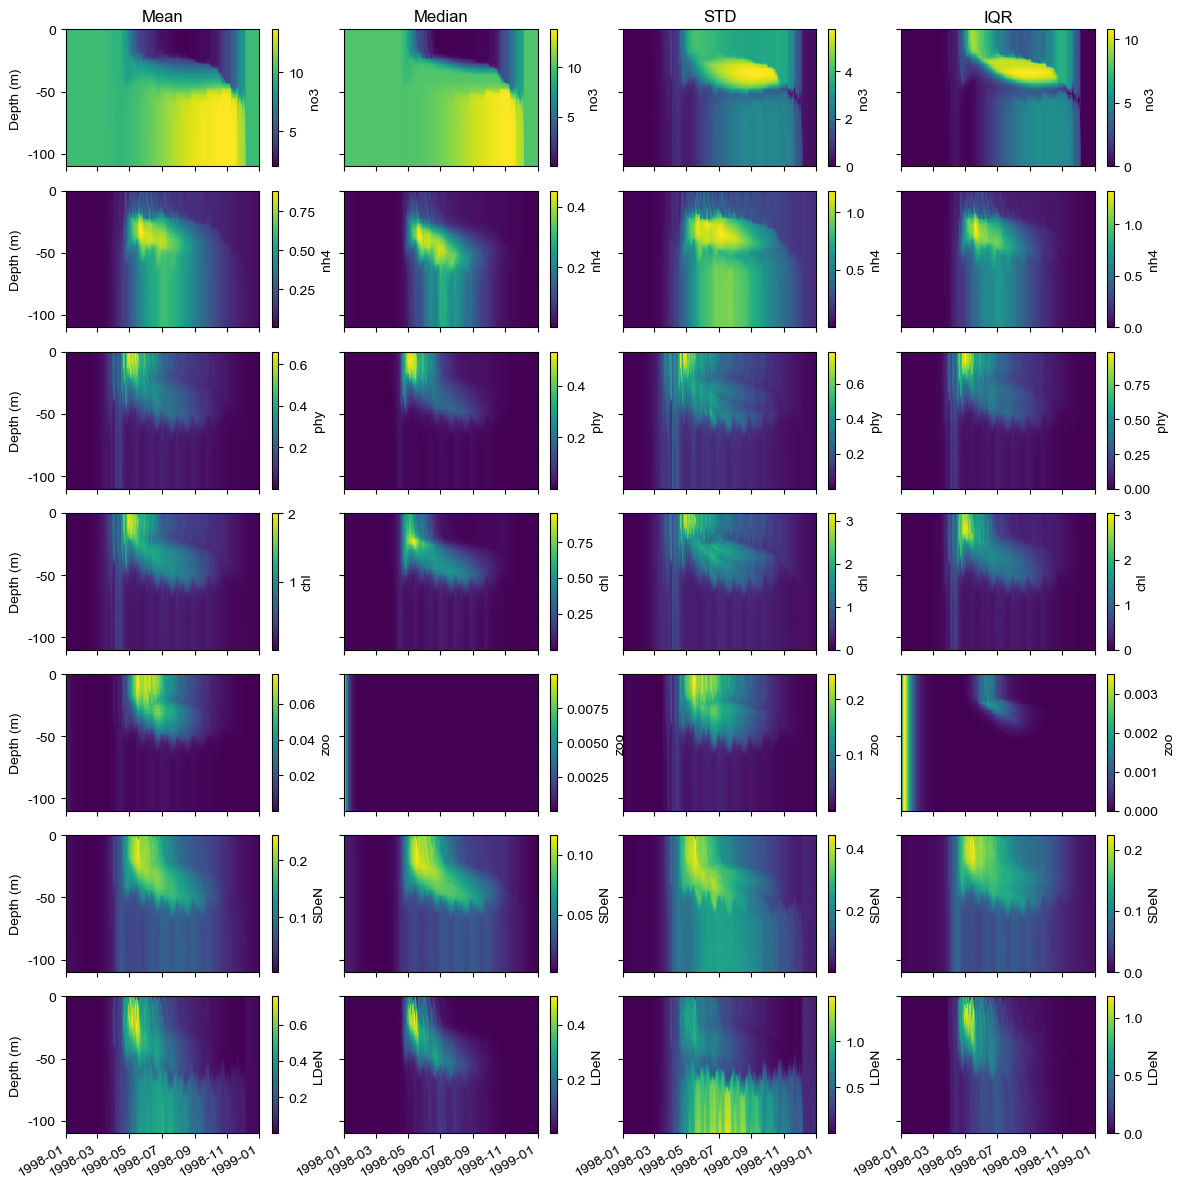

In [168]:
varlist = ["no3","nh4","phy","chl","zoo","SDeN","LDeN"]


fig, axs = plt.subplots(7, 4, figsize=(12,12), sharex=True, sharey=True)

for j in range(np.size(varlist)):
    output = ds['1p1z_'+varlist[j]]

    mesh = axs[j, 0].pcolormesh(time,z,np.squeeze(output.mean(axis=0)).T)
    plt.colorbar(mesh).set_label(varlist[j])
    axs[j, 0].set_ylabel('Depth (m)')
    if j == 0:
        axs[j, 0].set_title('Mean')
    mesh = axs[j, 1].pcolormesh(time,z,np.squeeze(output.median(axis=0)).T)
    plt.colorbar(mesh).set_label(varlist[j])
    if j == 0:
        axs[j, 1].set_title('Median')
    mesh = axs[j, 2].pcolormesh(time,z,np.squeeze(output.std(axis=0)).T)
    plt.colorbar(mesh).set_label(varlist[j])
    if j == 0:
        axs[j, 2].set_title('STD')
    mesh = axs[j, 3].pcolormesh(time,z,np.squeeze(iqr(output,0)).T)
    plt.colorbar(mesh).set_label(varlist[j])
    if j == 0:
        axs[j, 3].set_title('IQR')

fig.autofmt_xdate()
plt.tight_layout()
# Manually adjust spacing (left, bottom, right, top, wspace, hspace)
plt.subplots_adjust(wspace=0.15)  # Adjust vertical spacing between subplots

fig.savefig('fig-tz-bgc-'+str(N),dpi=300,bbox_inches='tight')

### Background physical environment (temperature, salinity, and density)

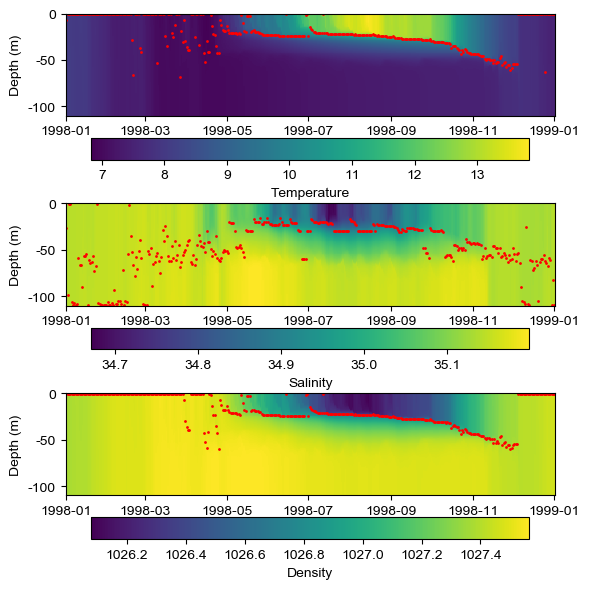

In [123]:
fig, axs = plt.subplots(3, 1, figsize=(6,6))

mesh = axs[0].pcolormesh(time,z,ds['temp'][0,:,:,0,0].T)
plt.colorbar(mesh,orientation='horizontal').set_label('Temperature')
axs[0].set_ylabel('Depth (m)')
mesh = axs[1].pcolormesh(time,z,ds['salt'][0,:,:,0,0].T)
plt.colorbar(mesh,orientation='horizontal').set_label('Salinity')
axs[1].set_ylabel('Depth (m)')
mesh = axs[2].pcolormesh(time,z,ds['rho'][0,:,:,0,0].T)
plt.colorbar(mesh,orientation='horizontal').set_label('Density')
axs[2].set_ylabel('Depth (m)')

thermocline_depth = np.zeros(len(time))  # Array to store thermocline depths
halocline_depth = np.zeros(len(time))  # Array to store thermocline depths
pycnocline_depth = np.zeros(len(time))  # Array to store thermocline depths
for t in range(len(time)):
    gradient = np.gradient(ds['temp'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    thermocline_depth[t] = z[max_gradient_index]
    gradient = np.gradient(ds['salt'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    halocline_depth[t] = z[max_gradient_index]
    gradient = np.gradient(ds['rho'][0,t,:,0,0], z, axis=0)
    max_gradient_index = np.argmax(np.abs(gradient))
    pycnocline_depth[t] = z[max_gradient_index]
mesh = axs[0].scatter(time,thermocline_depth,c='r',s=1)
mesh = axs[1].scatter(time,halocline_depth,c='r',s=1)
mesh = axs[2].scatter(time,pycnocline_depth,c='r',s=1)

#fig.autofmt_xdate()
plt.tight_layout()
# Manually adjust spacing (left, bottom, right, top, wspace, hspace)
plt.subplots_adjust(hspace=0.3)  # Adjust vertical spacing between subplots

fig.savefig('fig-tz-tsrho-'+str(N),dpi=300,bbox_inches='tight')